# Project: Loan Default Prediction System¶

# Author: Zainul Abedeen

# Description: A machine learning model to predict loan default risks.

# Data Description:

Data Documentation: The dataset consists of various features that describe loan applicants, their financial background, and other demographic information. Below is a detailed description of each column used in the analysis:

- Age Type: Numeric

Description: The age of the loan applicant in years.

Importance: Age is often an important factor when assessing loan eligibility or predicting the likelihood of default. Older individuals may have more stable income and less risk of default, but this is not always the case.

- Income Type: Numeric

Description: The annual income of the loan applicant in dollars.

Importance: Income is a key factor in evaluating an applicant’s ability to repay a loan. Higher income generally correlates with a lower risk of default.

- LoanAmount Type: Numeric

Description: The total loan amount requested by the applicant.

Importance: The loan amount can influence the risk of default. Larger loans may carry higher risks, particularly if the applicant's income is not substantial enough to support it.

- CreditScore Type: Numeric

Description: The credit score of the loan applicant.

Importance: Credit score is one of the most important indicators of creditworthiness. A higher score generally means lower risk, as the applicant has a history of managing credit responsibly.

- MonthsEmployed Type: Numeric

Description: The number of months the applicant has been employed at their current job.

Importance: This feature provides an indication of job stability. Longer employment may correlate with a stable income and, consequently, a lower risk of loan default.

- NumCreditLines Type: Numeric

Description: The number of credit lines (e.g., credit cards, mortgages) the applicant currently holds.

Importance: A higher number of credit lines could indicate a greater level of financial responsibility or the possibility of overextension of credit.

- InterestRate Type: Numeric

Description: The interest rate applied to the loan.

Importance: A higher interest rate may indicate greater financial risk or less favorable terms for the applicant, often associated with a higher likelihood of default.

- LoanTerm Type: Numeric

Description: The loan term in months.

Importance: Loan term affects monthly payments and total interest paid. Shorter loan terms may have higher monthly payments but lower total interest, while longer terms may have lower payments but higher total interest.

- DTIRatio (Debt-to-Income Ratio) Type: Numeric

Description: The ratio of the applicant's total debt to their income.

Importance: This is a critical indicator of an applicant’s ability to repay the loan. A higher DTI ratio indicates that the applicant may already be financially stretched and at higher risk of default.

- Default Type: Categorical (Binary)

Description: The target variable indicating whether the loan applicant defaulted (1) or did not default (0).

Importance: This is the outcome we are trying to predict. The model uses other features in the dataset to predict this variable.

- Education Type: Categorical

Description: The highest level of education attained by the applicant.

Categories:

0: No formal education

1: High school or equivalent

2: Undergraduate degree

3: Postgraduate degree

Importance: Education level can affect earning potential and financial stability, potentially influencing the risk of loan default.

- EmploymentType Type: Categorical

Description: The type of employment the applicant has.

Categories:

0: Unemployed

1: Self-employed

2: Employed full-time

Importance: Employment type may indicate the stability of income. Self-employed individuals might experience income volatility, while full-time employed individuals generally have more stable incomes.

- MaritalStatus Type: Categorical

Description: The marital status of the applicant.

Categories:

0: Single

1: Married

2: Divorced

Importance: Marital status can influence financial stability. Married individuals may have dual incomes or shared financial responsibilities, while single individuals may bear all financial responsibility themselves.

- HasMortgage Type: Categorical (Binary)

Description: Indicates whether the applicant currently has a mortgage.

Categories:

0: No mortgage

1: Has mortgage

Importance: Having a mortgage implies an existing financial obligation, which could affect the applicant's ability to repay new loans.

- HasDependents Type: Categorical (Binary)

Description: Indicates whether the applicant has dependents (e.g., children, other dependents).

Categories:

0: No dependents

1: Has dependents

Importance: Applicants with dependents may face higher living costs, which could reduce their available income for repaying loans.

- LoanPurpose Type: Categorical

Description: The purpose for which the loan is being requested.

Categories:

0: Home purchase

1: Debt consolidation

2: Education

3: Medical expenses

Importance: The purpose of the loan can affect the applicant’s likelihood of default. Loans for essential purposes like home purchase or medical expenses may have a different repayment pattern than those for discretionary purposes like education.

- HasCoSigner Type: Categorical (Binary)

Description: Indicates whether the applicant has a co-signer for the loan.

Categories:

0: No co-signer

1: Has co-signer

Importance: Having a co-signer reduces the risk of default because the co-signer is responsible for repayment in case the primary borrower defaults.

In [125]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline as pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, make_scorer
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [126]:
df = pd.read_csv("data/Loan_default.csv")

In [127]:
df.shape

(255347, 18)

In [128]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [129]:
df.tail()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0
255346,ZTH91CGL0B,62,22418,18481,636,113,2,6.73,12,0.48,Bachelor's,Unemployed,Divorced,Yes,No,Education,Yes,0


In [130]:
df.columns.to_list()

['LoanID',
 'Age',
 'Income',
 'LoanAmount',
 'CreditScore',
 'MonthsEmployed',
 'NumCreditLines',
 'InterestRate',
 'LoanTerm',
 'DTIRatio',
 'Education',
 'EmploymentType',
 'MaritalStatus',
 'HasMortgage',
 'HasDependents',
 'LoanPurpose',
 'HasCoSigner',
 'Default']

In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [132]:
df['LoanPurpose'].value_counts()

LoanPurpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: count, dtype: int64

In [133]:
df.head(1)

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0


In [134]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [135]:
df.drop(columns='LoanID', inplace= True)

In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Age             255347 non-null  int64  
 1   Income          255347 non-null  int64  
 2   LoanAmount      255347 non-null  int64  
 3   CreditScore     255347 non-null  int64  
 4   MonthsEmployed  255347 non-null  int64  
 5   NumCreditLines  255347 non-null  int64  
 6   InterestRate    255347 non-null  float64
 7   LoanTerm        255347 non-null  int64  
 8   DTIRatio        255347 non-null  float64
 9   Education       255347 non-null  object 
 10  EmploymentType  255347 non-null  object 
 11  MaritalStatus   255347 non-null  object 
 12  HasMortgage     255347 non-null  object 
 13  HasDependents   255347 non-null  object 
 14  LoanPurpose     255347 non-null  object 
 15  HasCoSigner     255347 non-null  object 
 16  Default         255347 non-null  int64  
dtypes: float64

In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Age             255347 non-null  int64  
 1   Income          255347 non-null  int64  
 2   LoanAmount      255347 non-null  int64  
 3   CreditScore     255347 non-null  int64  
 4   MonthsEmployed  255347 non-null  int64  
 5   NumCreditLines  255347 non-null  int64  
 6   InterestRate    255347 non-null  float64
 7   LoanTerm        255347 non-null  int64  
 8   DTIRatio        255347 non-null  float64
 9   Education       255347 non-null  object 
 10  EmploymentType  255347 non-null  object 
 11  MaritalStatus   255347 non-null  object 
 12  HasMortgage     255347 non-null  object 
 13  HasDependents   255347 non-null  object 
 14  LoanPurpose     255347 non-null  object 
 15  HasCoSigner     255347 non-null  object 
 16  Default         255347 non-null  int64  
dtypes: float64

In [138]:
df.shape

(255347, 17)

In [139]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [140]:
bins = [0, 18, 30, 45, 60, 100]
labels = ['Child', 'Teenager', 'Adult', 'Senior', "Super Senior"]

# 'Age' column ko overwrite karne ki bajaye 'Age_Group' naya column banayein
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

df.head()


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,Age_Group
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0,Senior
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0,Super Senior
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1,Senior
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0,Adult
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0,Senior


In [141]:
df['Age'].unique()

array([56, 69, 46, 32, 60, 25, 38, 36, 40, 28, 41, 53, 57, 20, 39, 19, 61,
       47, 55, 50, 29, 42, 66, 44, 59, 45, 33, 64, 68, 54, 24, 26, 35, 21,
       31, 67, 43, 37, 52, 34, 23, 51, 27, 48, 65, 62, 58, 18, 22, 30, 49,
       63])

In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   Age             255347 non-null  int64   
 1   Income          255347 non-null  int64   
 2   LoanAmount      255347 non-null  int64   
 3   CreditScore     255347 non-null  int64   
 4   MonthsEmployed  255347 non-null  int64   
 5   NumCreditLines  255347 non-null  int64   
 6   InterestRate    255347 non-null  float64 
 7   LoanTerm        255347 non-null  int64   
 8   DTIRatio        255347 non-null  float64 
 9   Education       255347 non-null  object  
 10  EmploymentType  255347 non-null  object  
 11  MaritalStatus   255347 non-null  object  
 12  HasMortgage     255347 non-null  object  
 13  HasDependents   255347 non-null  object  
 14  LoanPurpose     255347 non-null  object  
 15  HasCoSigner     255347 non-null  object  
 16  Default         255347 non-null  int64

In [143]:
df['Age'].value_counts()

Age
55    5064
40    5056
65    5027
33    5022
53    5010
62    4999
34    4987
45    4985
61    4982
39    4973
22    4970
32    4969
43    4965
19    4963
35    4961
68    4958
38    4955
30    4954
49    4952
50    4949
27    4945
47    4931
57    4925
54    4921
31    4908
44    4906
36    4906
28    4906
56    4902
26    4891
21    4889
46    4887
18    4884
58    4883
67    4876
51    4876
59    4871
24    4869
29    4865
63    4862
20    4861
37    4856
66    4841
25    4840
64    4840
69    4817
41    4815
48    4810
42    4803
60    4772
52    4748
23    4740
Name: count, dtype: int64

In [144]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# 'Age' ki bajaye yaha 'Age_Group' daalein
columns_to_encode = ['Age_Group', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

label_mappings = {}

for col in columns_to_encode:
    df[col] = le.fit_transform(df[col])
    label_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

for col, mapping in label_mappings.items():
    print(f"Mapping for {col}: {mapping}")


Mapping for Age_Group: {'Adult': np.int64(0), 'Child': np.int64(1), 'Senior': np.int64(2), 'Super Senior': np.int64(3), 'Teenager': np.int64(4)}
Mapping for Education: {"Bachelor's": np.int64(0), 'High School': np.int64(1), "Master's": np.int64(2), 'PhD': np.int64(3)}
Mapping for EmploymentType: {'Full-time': np.int64(0), 'Part-time': np.int64(1), 'Self-employed': np.int64(2), 'Unemployed': np.int64(3)}
Mapping for MaritalStatus: {'Divorced': np.int64(0), 'Married': np.int64(1), 'Single': np.int64(2)}
Mapping for HasMortgage: {'No': np.int64(0), 'Yes': np.int64(1)}
Mapping for HasDependents: {'No': np.int64(0), 'Yes': np.int64(1)}
Mapping for LoanPurpose: {'Auto': np.int64(0), 'Business': np.int64(1), 'Education': np.int64(2), 'Home': np.int64(3), 'Other': np.int64(4)}
Mapping for HasCoSigner: {'No': np.int64(0), 'Yes': np.int64(1)}


In [145]:
# 1. Monthly Installment Estimate (Simple Interest version for approximation)
# Total Payback = Principal + (Principal * Rate)
# Monthly = Total Payback / Term
total_payback = df['LoanAmount'] * (1 + (df['InterestRate'] / 100))
df['Monthly_Payment'] = total_payback / df['LoanTerm']

# 2. Payment-to-Income Ratio (PTI)
# Kitni salary installment mein ja rhi hai
df['PTI_Ratio'] = df['Monthly_Payment'] / (df['Income'] / 12)

# 3. Employment Stability Factor
# Age ke hisaab se kitne % waqt se job kar rhe hain
# (Age ko months mein convert karke divide kiya)
df['Job_Stability_Index'] = df['MonthsEmployed'] / (df['Age'] * 12)

# 4. Debt per Credit Line
# Har credit line par kitna bojh hai
df['Debt_per_Line'] = df['LoanAmount'] / (df['NumCreditLines'] + 1)

# 5. Young & High Debt Flag (Risk Indicator)
# Agar age kam hai aur loan amount boht zyada
df['Young_High_Risk'] = ((df['Age'] < 30) & (df['LoanAmount'] > df['LoanAmount'].median())).astype(int)



# Apply the function
# df = engineer_features(df)
print("New features 'PTI_Ratio', 'Job_Stability_Index', and 'Debt_per_Line' created!")

New features 'PTI_Ratio', 'Job_Stability_Index', and 'Debt_per_Line' created!


In [146]:
df.drop('Age', inplace=True,axis=1)

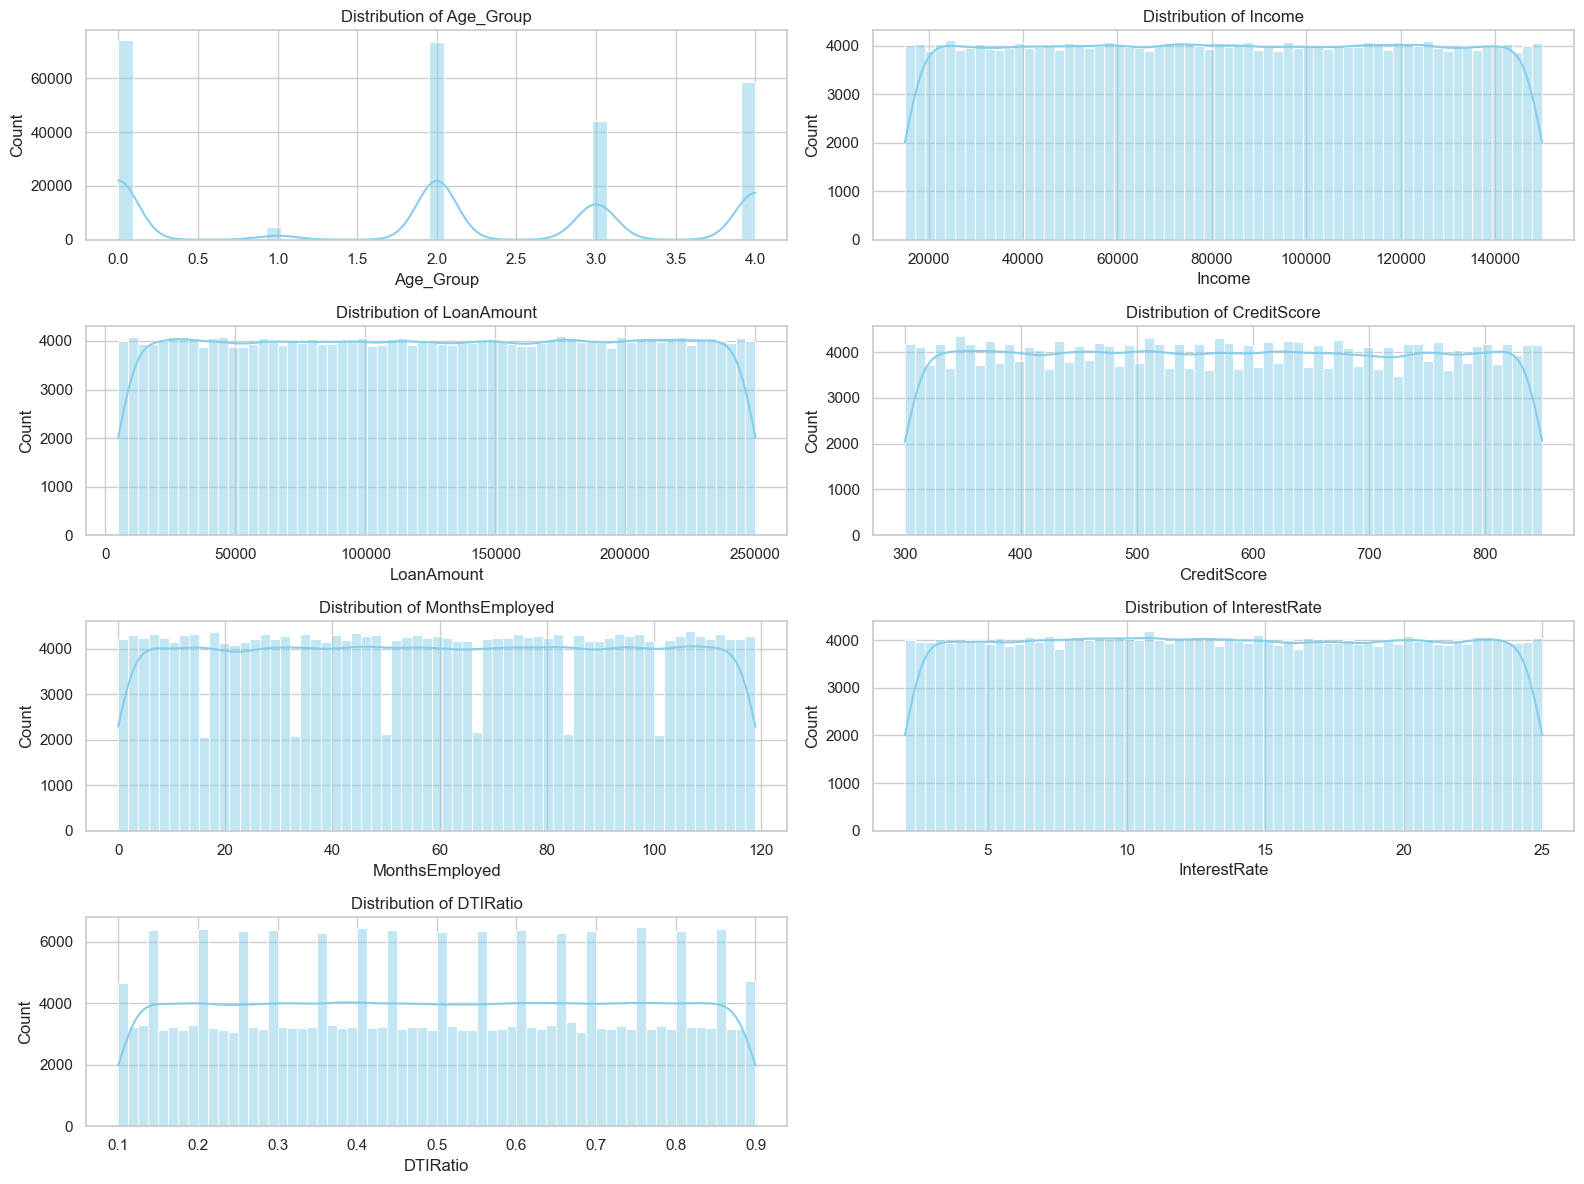

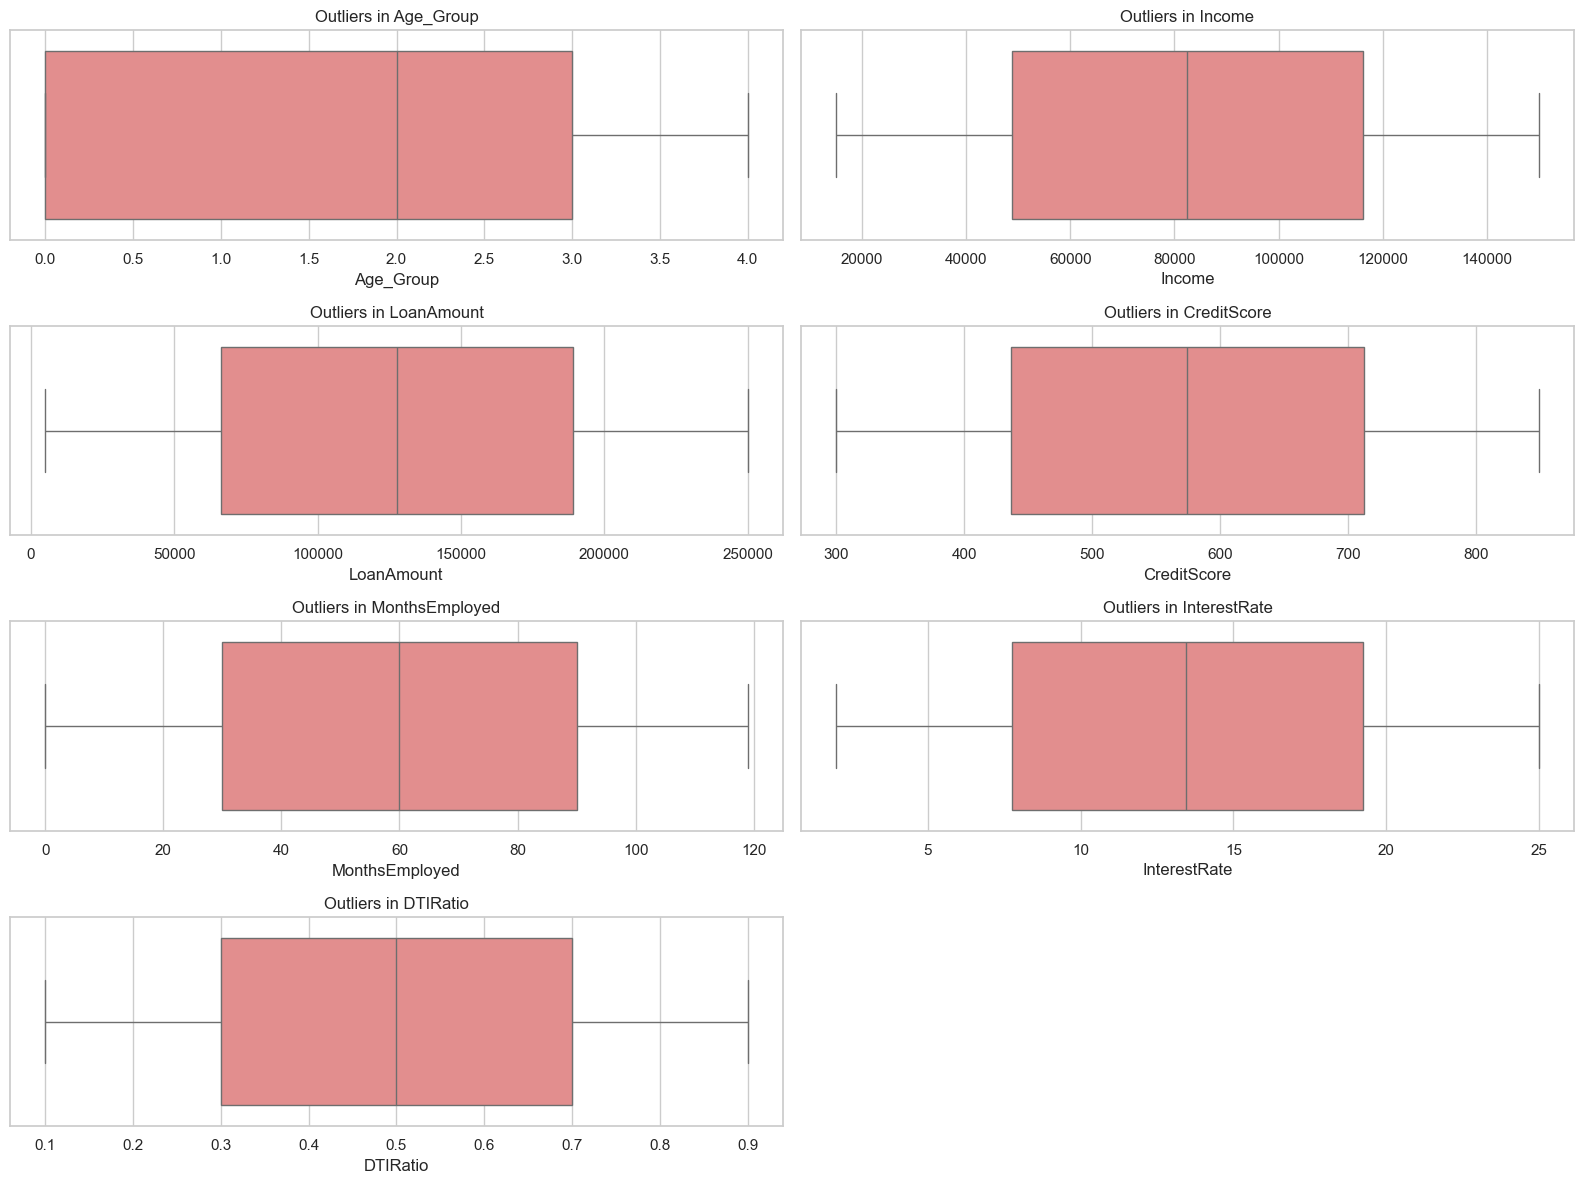

In [147]:
# List of numerical columns
numerical_cols = ['Age_Group', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'InterestRate', 'DTIRatio']

# Setting up the figure for multiple subplots
plt.figure(figsize=(16, 12))

for i, col in enumerate(numerical_cols):
    # Plotting Histogram with KDE to see distribution
    plt.subplot(4, 2, i + 1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()

plt.show()

# Plotting Boxplots to detect outliers
plt.figure(figsize=(16, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 2, i + 1)
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Outliers in {col}')
    plt.tight_layout()

plt.show()

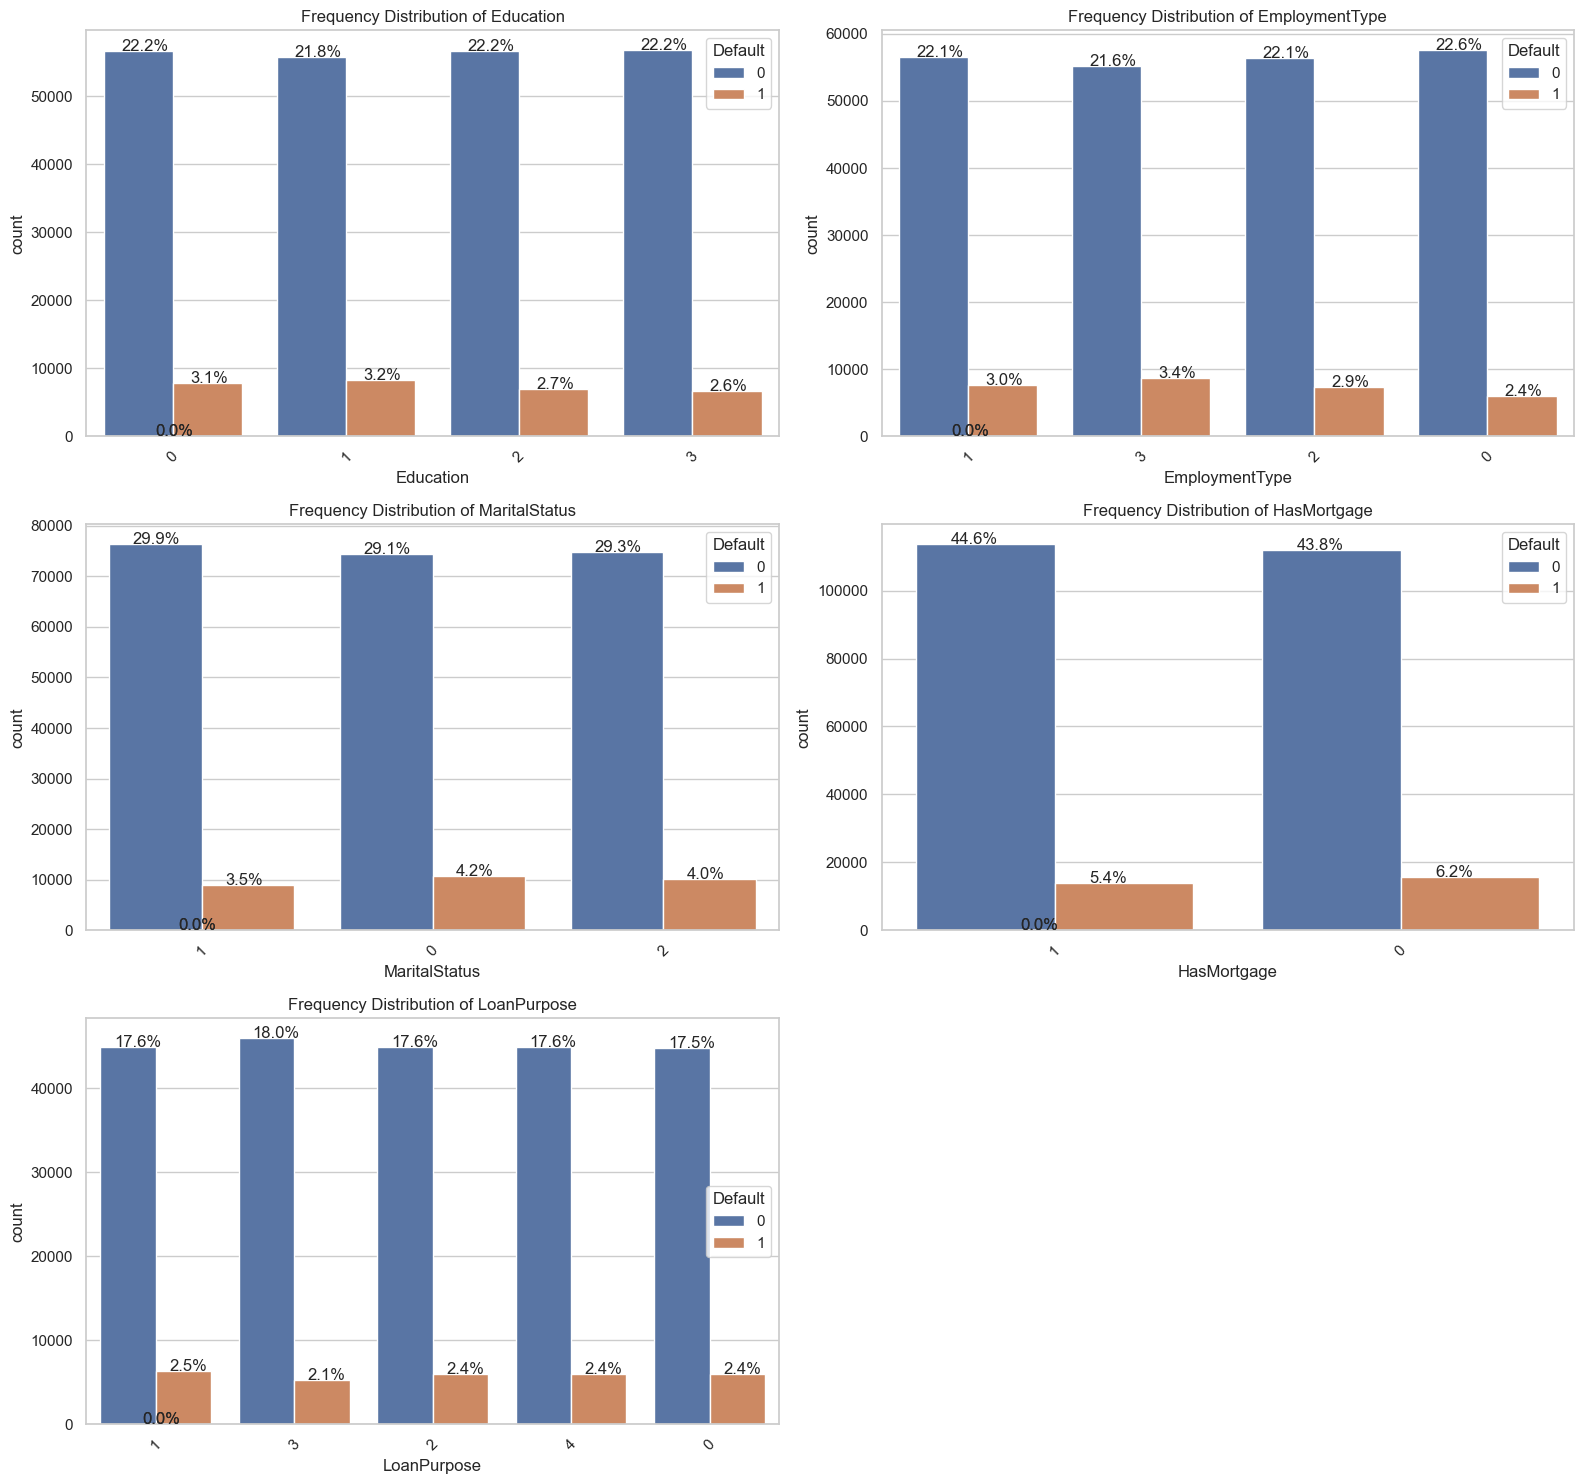

In [148]:
# List of categorical columns
categorical_cols = ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'LoanPurpose']

plt.figure(figsize=(16, 15))

for i, col in enumerate(categorical_cols):
    plt.subplot(3, 2, i + 1)
    
    # Count Plot
    sns.countplot(data=df, x=col, hue='Default', order=df[col].value_counts().index)
    
    # Adding percentages on top of bars
    total = len(df[col])
    for p in plt.gca().patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total)
        x = p.get_x() + p.get_width() / 2 - 0.1
        y = p.get_y() + p.get_height()
        plt.gca().annotate(percentage, (x, y), size=12)
        
    plt.title(f'Frequency Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.show()

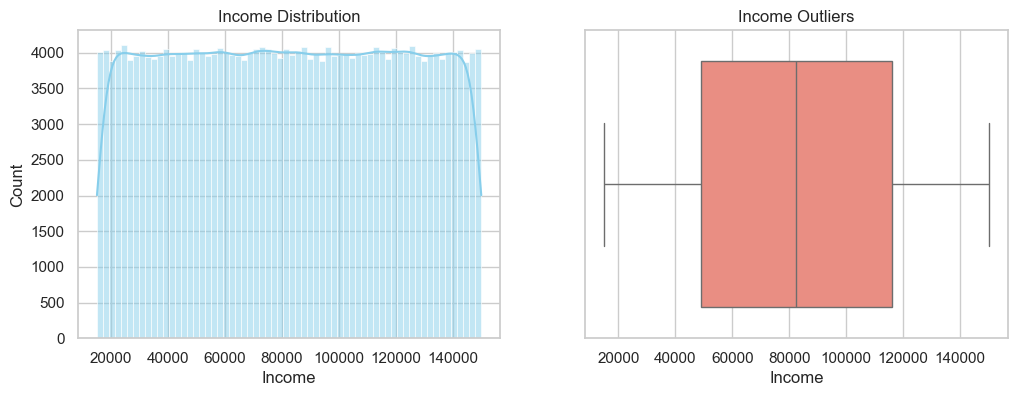

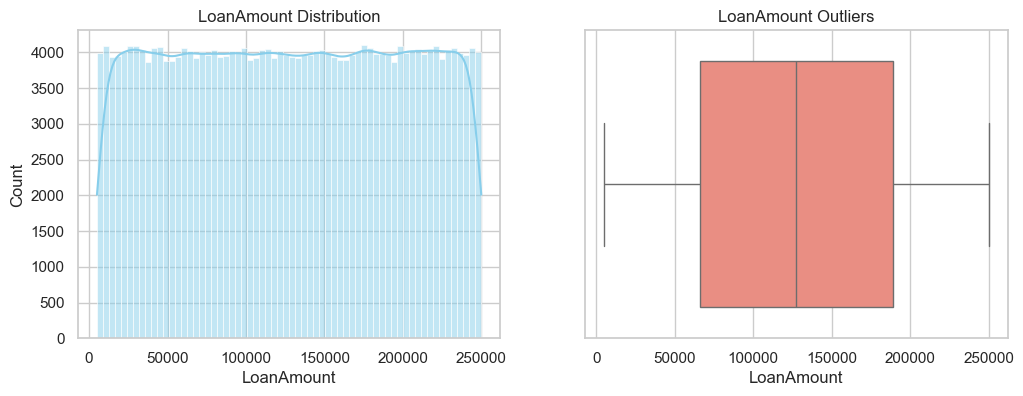

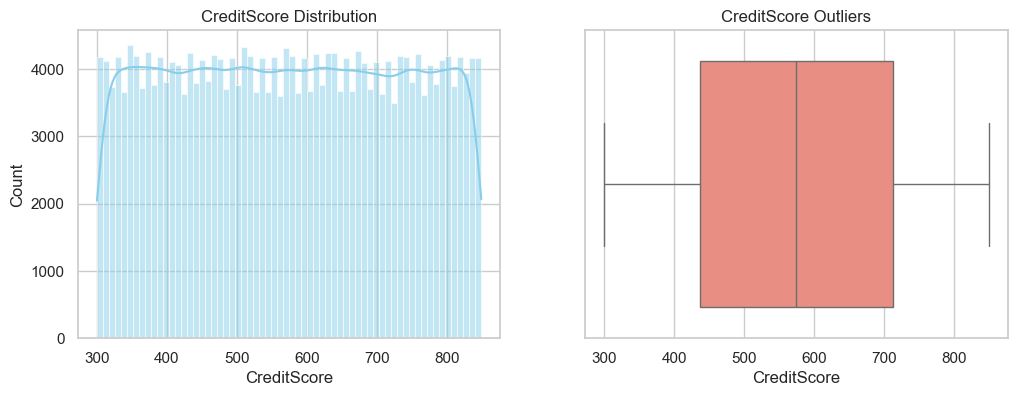

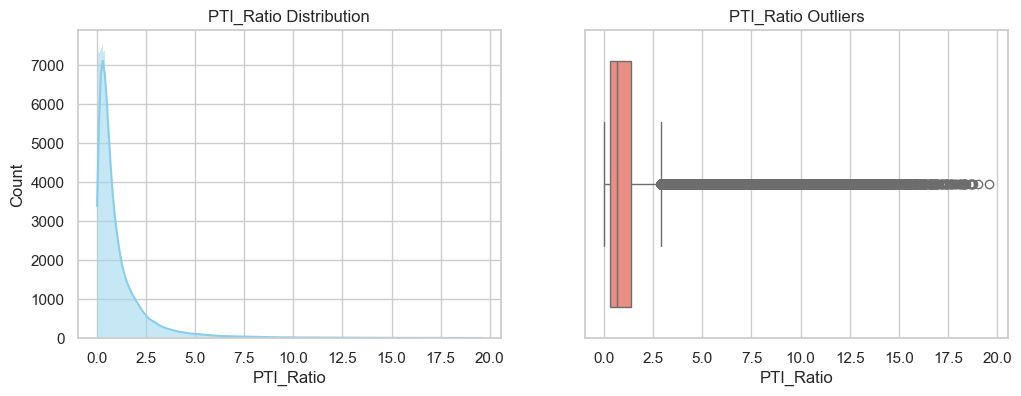

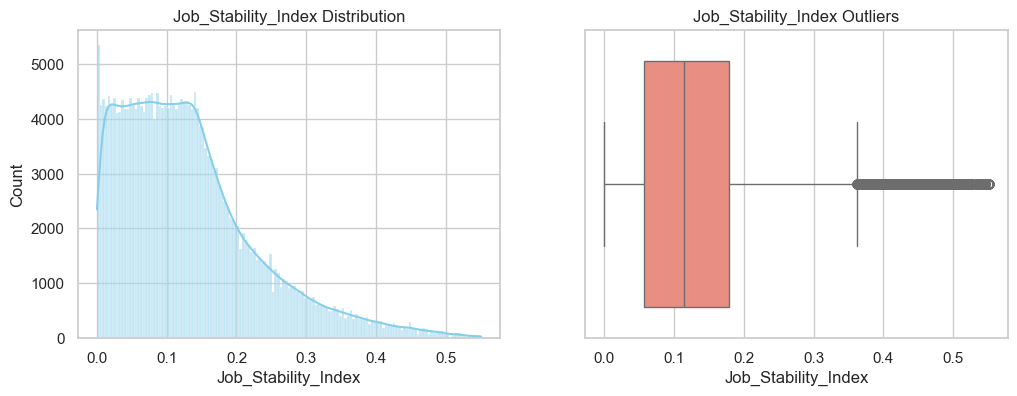

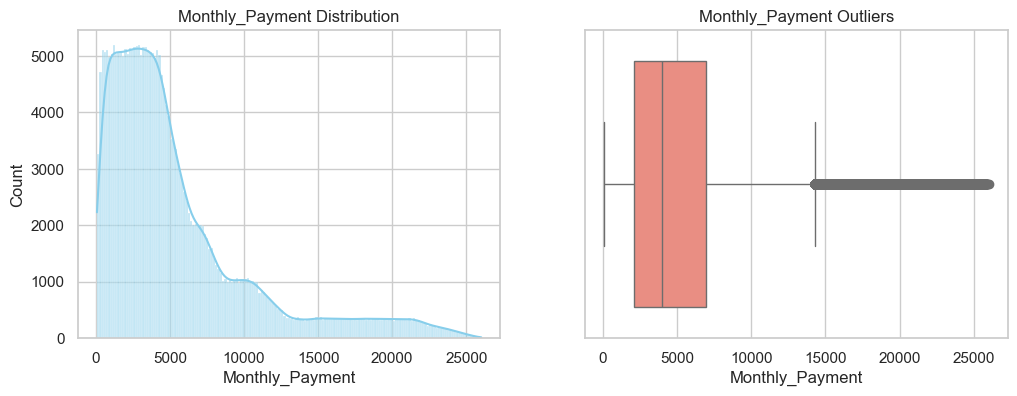

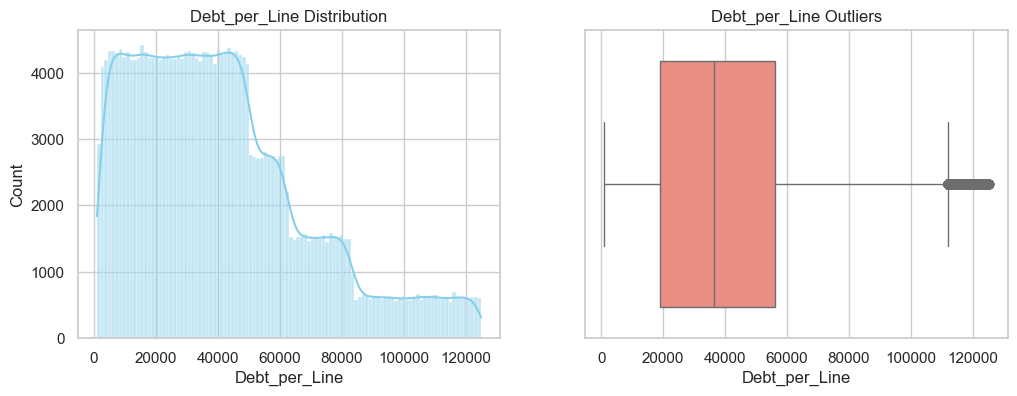

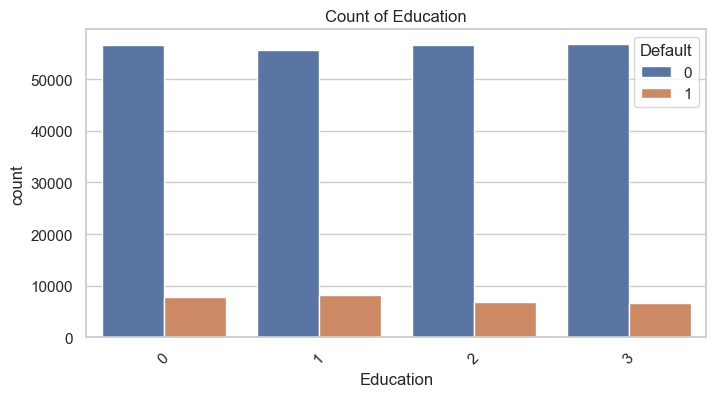

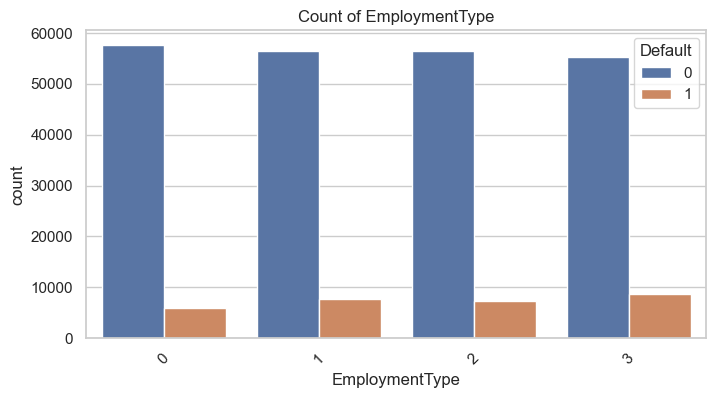

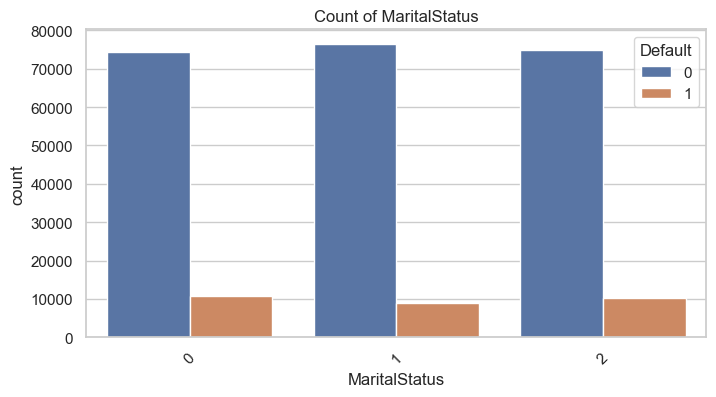

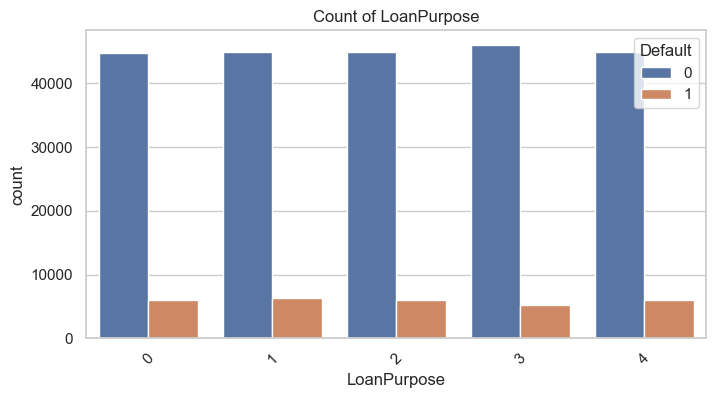

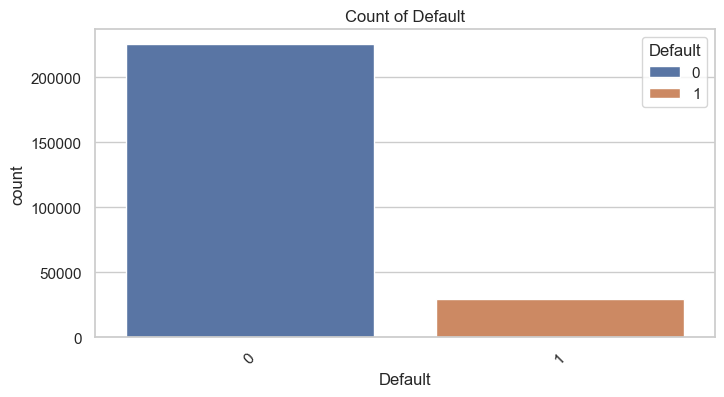

In [149]:

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

def univariate_analysis(df):
    # Numerical Features list
    num_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore', 
                'PTI_Ratio', 'Job_Stability_Index', 'Monthly_Payment', 'Debt_per_Line']
    
    for col in num_cols:
        # Check agar column exist karta hai (Safety Check)
        if col in df.columns:
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            sns.histplot(df[col], kde=True, ax=axes[0], color='skyblue').set_title(f'{col} Distribution')
            sns.boxplot(x=df[col], ax=axes[1], color='salmon').set_title(f'{col} Outliers')
            plt.show()
        else:
            print(f"Warning: Column '{col}' not found in DataFrame.")

    # Categorical Features
    cat_cols = ['Education', 'EmploymentType', 'MaritalStatus', 'LoanPurpose', 'Default']
    for col in cat_cols:
        if col in df.columns:
            plt.figure(figsize=(8, 4))
            sns.countplot(data=df, x=col, hue="Default")
            plt.title(f'Count of {col}')
            plt.xticks(rotation=45)
            plt.show()

# Final Call
univariate_analysis(df)

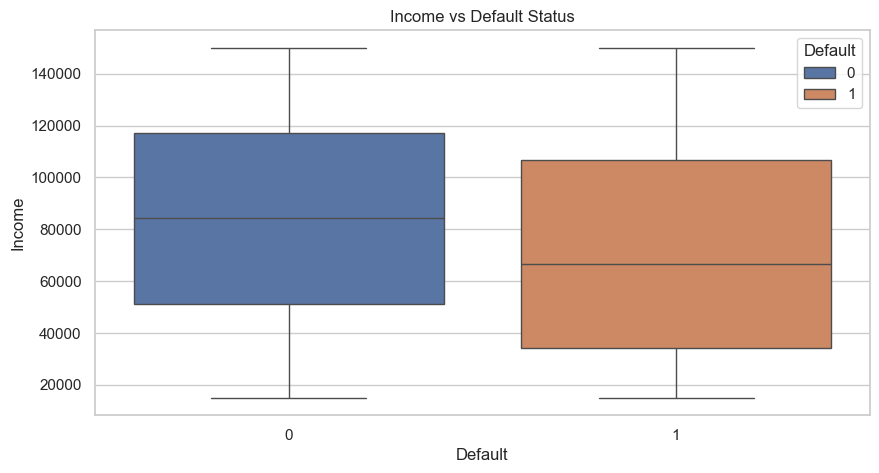

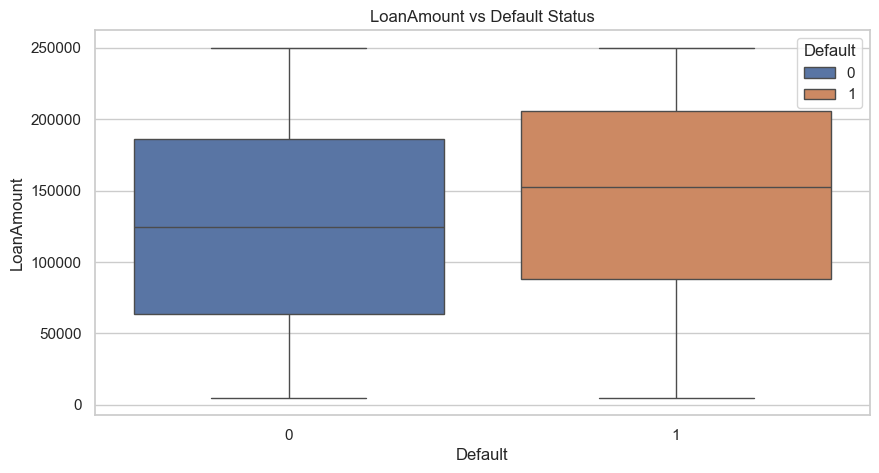

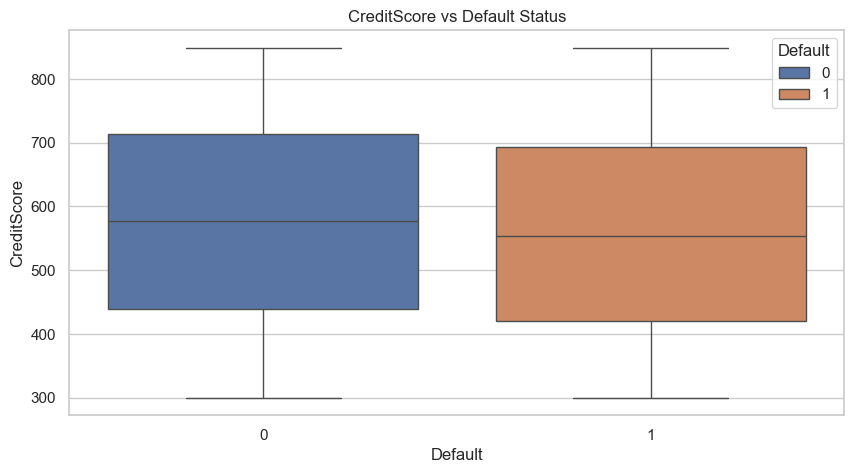

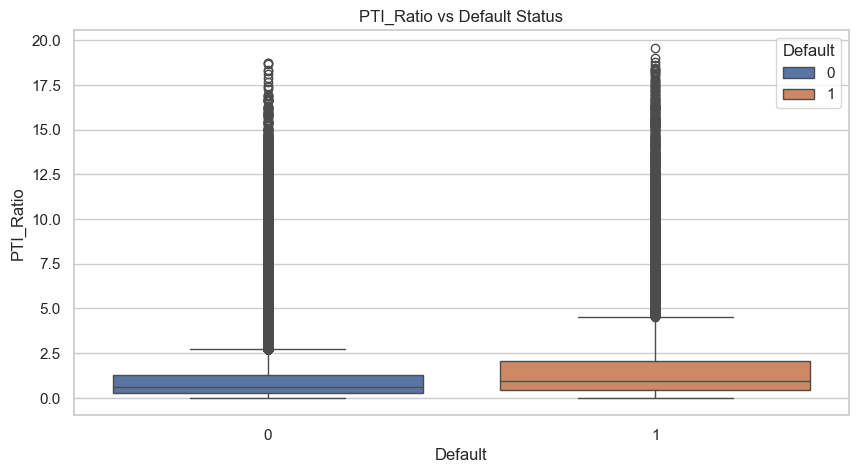

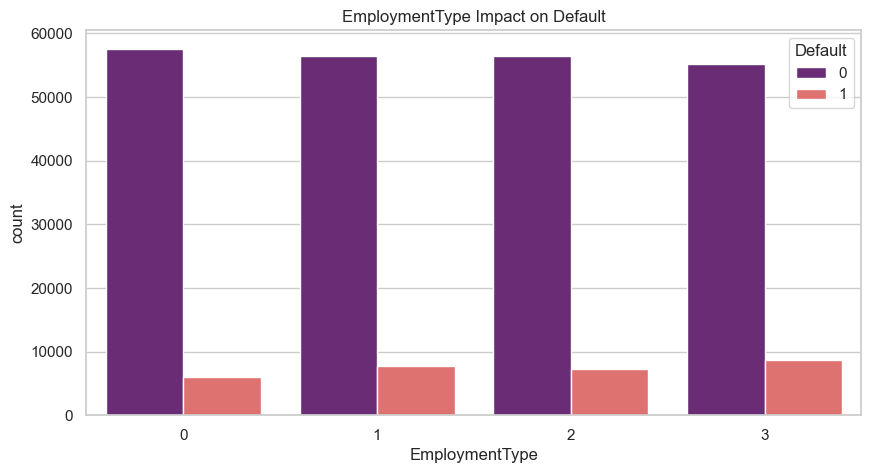

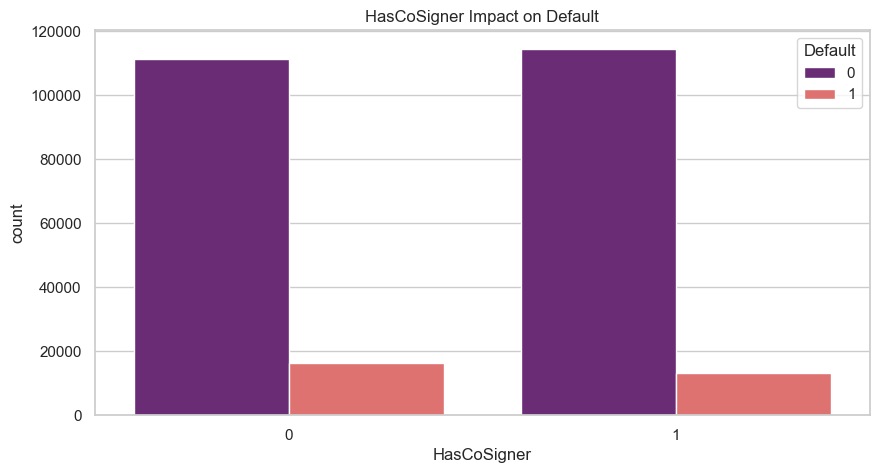

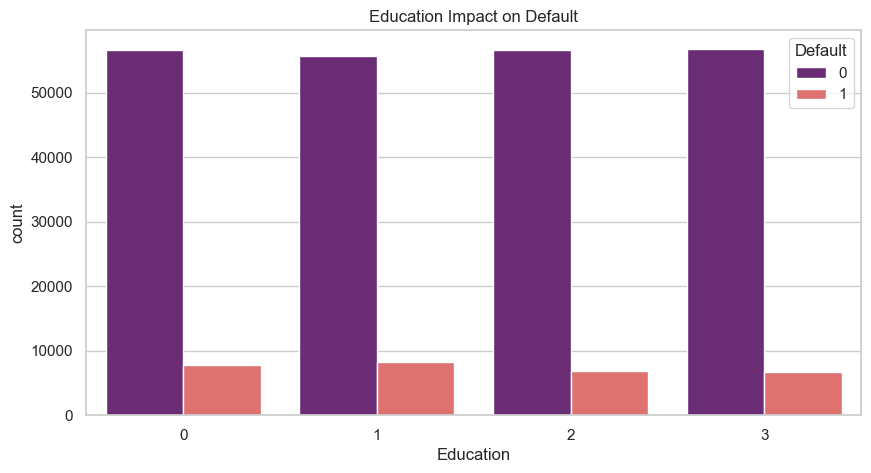

In [150]:
def bivariate_analysis(df):
    # Numeric vs Target (Using Boxenplots for better density visualization)
    num_cols = ['Income', 'LoanAmount', 'CreditScore', 'PTI_Ratio']
    for col in num_cols:
        plt.figure(figsize=(10, 5))
        sns.boxplot(x='Default', y=col, data=df, hue="Default")
        plt.title(f'{col} vs Default Status')
        plt.show()

    # Categorical vs Target (Stacked Bar Chart / Proportion)
    cat_cols = ['EmploymentType', 'HasCoSigner', 'Education']
    for col in cat_cols:
        plt.figure(figsize=(10, 5))
        # Hue se humein Default vs Non-Default ka ratio mil jayega
        sns.countplot(data=df, x=col, hue='Default', palette='magma')
        plt.title(f'{col} Impact on Default')
        plt.show()

bivariate_analysis(df)

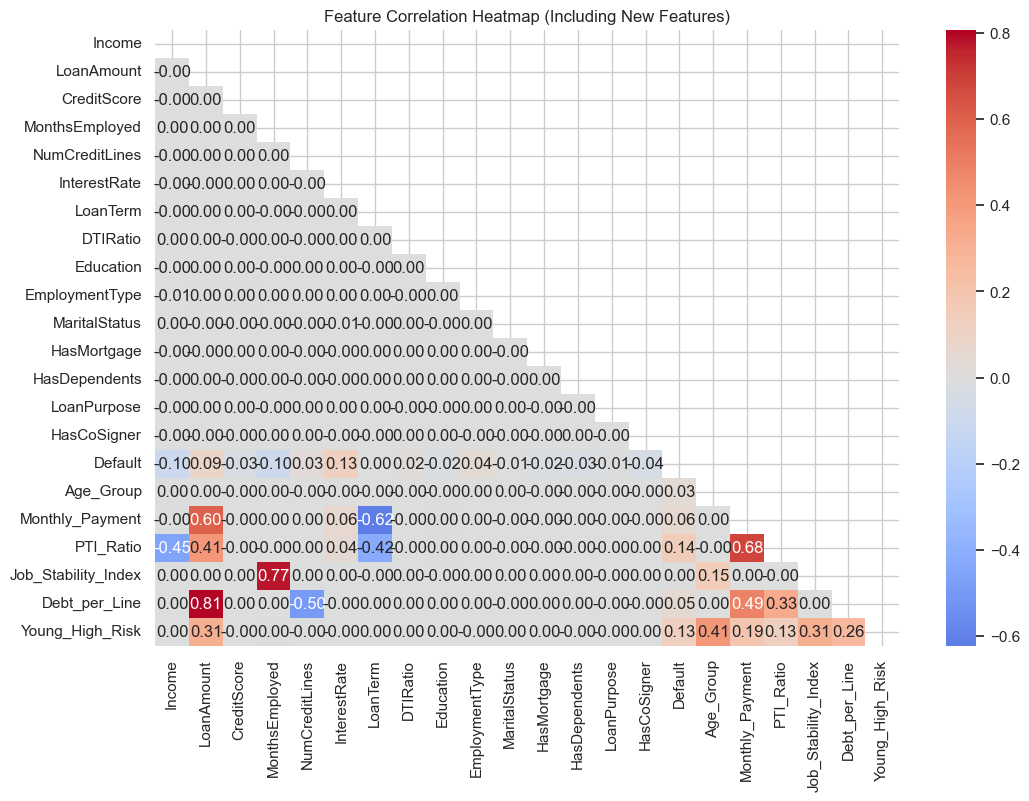

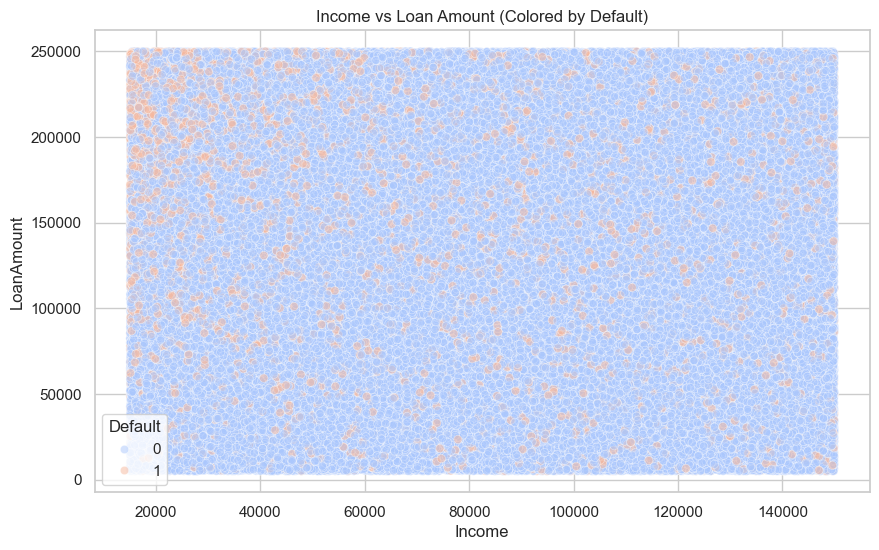

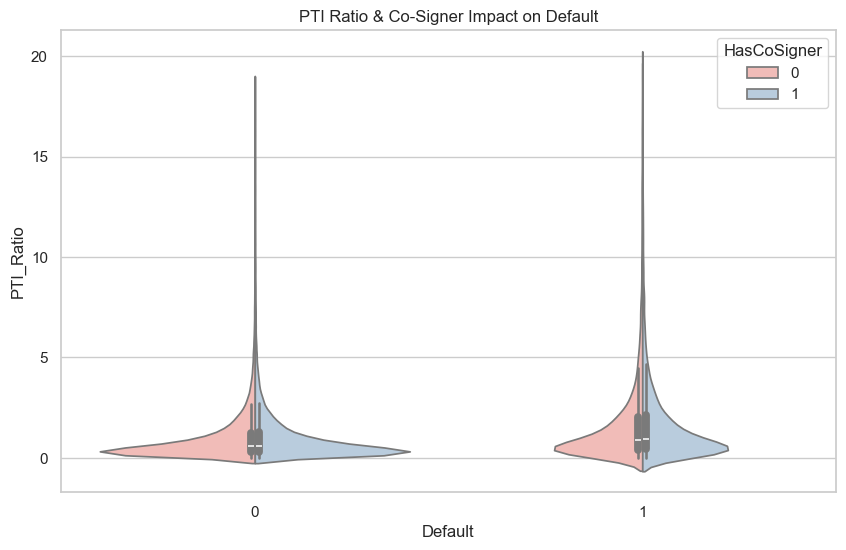

In [151]:
def multivariate_analysis(df):
    # 1. Correlation Heatmap
    # Sirf numeric columns ka correlation
    plt.figure(figsize=(12, 8))
    numeric_df = df.select_dtypes(include=[np.number])
    corr = numeric_df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool)) # Half triangle for clarity
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0)
    plt.title('Feature Correlation Heatmap (Including New Features)')
    plt.show()

    # 2. Scatter Plot for Interaction
    # Example: Income vs LoanAmount colored by Default
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='Income', y='LoanAmount', hue='Default', alpha=0.5, palette='coolwarm')
    plt.title('Income vs Loan Amount (Colored by Default)')
    plt.show()

    # 3. New Feature Interaction
    # PTI_Ratio vs Job_Stability vs Default
    plt.figure(figsize=(10, 6))
    sns.violinplot(data=df, x='Default', y='PTI_Ratio', hue='HasCoSigner', split=True, palette='Pastel1')
    plt.title('PTI Ratio & Co-Signer Impact on Default')
    plt.show()

multivariate_analysis(df)

In [152]:
num_df = df.select_dtypes(include=np.number)

Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_df = ((num_df < lower) | (num_df > upper)).sum() / len(df) * 100
outlier_df = outlier_df.round(2).sort_values(ascending=False)

print(outlier_df)

Default                11.61
Young_High_Risk        11.48
PTI_Ratio               8.18
Monthly_Payment         8.03
Job_Stability_Index     3.46
Debt_per_Line           2.67
LoanAmount              0.00
Age_Group               0.00
HasCoSigner             0.00
LoanPurpose             0.00
HasDependents           0.00
Income                  0.00
MaritalStatus           0.00
EmploymentType          0.00
Education               0.00
DTIRatio                0.00
LoanTerm                0.00
InterestRate            0.00
NumCreditLines          0.00
MonthsEmployed          0.00
CreditScore             0.00
HasMortgage             0.00
dtype: float64


In [153]:
target = 'Default'

# Select numeric columns except target
num_cols = df.select_dtypes(include=np.number).columns.drop(target)

for col in num_cols:
    
    # Calculate Q1, Q3, IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define bounds
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Median
    median = df[col].median()

    # Replace outliers with median
    df[col] = np.where(
        (df[col] < lower) | (df[col] > upper),
        median,
        df[col]
    )

print("Outliers replaced successfully ")
print(df.head())

Outliers replaced successfully 
    Income  LoanAmount  CreditScore  MonthsEmployed  NumCreditLines  \
0  85994.0     50587.0        520.0            80.0             4.0   
1  50432.0    124440.0        458.0            15.0             1.0   
2  84208.0    129188.0        451.0            26.0             3.0   
3  31713.0     44799.0        743.0             0.0             3.0   
4  20437.0      9139.0        633.0             8.0             4.0   

   InterestRate  LoanTerm  DTIRatio  Education  EmploymentType  ...  \
0         15.23      36.0      0.44        0.0             0.0  ...   
1          4.81      60.0      0.68        2.0             0.0  ...   
2         21.17      24.0      0.31        2.0             3.0  ...   
3          7.07      24.0      0.23        1.0             0.0  ...   
4          6.51      48.0      0.73        0.0             3.0  ...   

   HasDependents  LoanPurpose  HasCoSigner  Default  Age_Group  \
0            1.0          4.0          1.0      

In [154]:
df.shape


(255347, 22)

In [155]:
print(df.shape)
df.head(1)

(255347, 22)


,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,...,HasDependents,LoanPurpose,HasCoSigner,Default,Age_Group,Monthly_Payment,PTI_Ratio,Job_Stability_Index,Debt_per_Line,Young_High_Risk
0,85994.0,50587.0,520.0,80.0,4.0,15.23,36.0,0.44,0.0,0.0,...,1.0,4.0,1.0,0,2.0,1619.205558,0.225951,0.119048,10117.4,0.0


In [156]:
from scipy import stats

group0 = df[df['Default'] == 0]['Income']
group1 = df[df['Default'] == 1]['Income']

t_stat, p_val = stats.ttest_ind(group0, group1)
print(f"T-statistic: {t_stat}, P-value: {p_val}")

if p_val < 0.05:
    print("Result: Null Hypothesis reject hoti hai. Income matters!")
else:
    print("Result: Income ka default par koi significant asar nahi dikha.")


T-statistic: 50.33460480989034, P-value: 0.0
Result: Null Hypothesis reject hoti hai. Income matters!


In [157]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

columns_to_encode = ['Age_Group', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

label_mappings = {}

for col in columns_to_encode:
    df[col] = le.fit_transform(df[col])
    label_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))


for col, mapping in label_mappings.items():
    print(f"Mapping for {col}: {mapping}")

Mapping for Age_Group: {np.float64(0.0): np.int64(0), np.float64(1.0): np.int64(1), np.float64(2.0): np.int64(2), np.float64(3.0): np.int64(3), np.float64(4.0): np.int64(4)}
Mapping for Education: {np.float64(0.0): np.int64(0), np.float64(1.0): np.int64(1), np.float64(2.0): np.int64(2), np.float64(3.0): np.int64(3)}
Mapping for EmploymentType: {np.float64(0.0): np.int64(0), np.float64(1.0): np.int64(1), np.float64(2.0): np.int64(2), np.float64(3.0): np.int64(3)}
Mapping for MaritalStatus: {np.float64(0.0): np.int64(0), np.float64(1.0): np.int64(1), np.float64(2.0): np.int64(2)}
Mapping for HasMortgage: {np.float64(0.0): np.int64(0), np.float64(1.0): np.int64(1)}
Mapping for HasDependents: {np.float64(0.0): np.int64(0), np.float64(1.0): np.int64(1)}
Mapping for LoanPurpose: {np.float64(0.0): np.int64(0), np.float64(1.0): np.int64(1), np.float64(2.0): np.int64(2), np.float64(3.0): np.int64(3), np.float64(4.0): np.int64(4)}
Mapping for HasCoSigner: {np.float64(0.0): np.int64(0), np.float6

In [158]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='Default')
y = df['Default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [159]:
df["Default"].value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Income               255347 non-null  float64
 1   LoanAmount           255347 non-null  float64
 2   CreditScore          255347 non-null  float64
 3   MonthsEmployed       255347 non-null  float64
 4   NumCreditLines       255347 non-null  float64
 5   InterestRate         255347 non-null  float64
 6   LoanTerm             255347 non-null  float64
 7   DTIRatio             255347 non-null  float64
 8   Education            255347 non-null  int64  
 9   EmploymentType       255347 non-null  int64  
 10  MaritalStatus        255347 non-null  int64  
 11  HasMortgage          255347 non-null  int64  
 12  HasDependents        255347 non-null  int64  
 13  LoanPurpose          255347 non-null  int64  
 14  HasCoSigner          255347 non-null  int64  
 15  Default          

In [161]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
import lightgbm as lgb
import xgboost as xgb

In [162]:
# Initialize classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(n_estimators=50, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50),
    'AdaBoost': AdaBoostClassifier(n_estimators=50),
    'Support Vector Classifier': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(),
    'LightGBM': lgb.LGBMClassifier(),
    'XGBoost': xgb.XGBClassifier(eval_metric='mlogloss')
}

In [163]:
# Train and evaluate each classifier
results = {}
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

# Print results
for name, accuracy in results.items():
    print(f"{name}: {accuracy:.4f}")


/Users/Apple/ZAINUL_AI/DS/ML-Project/Loan Default Prediction/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Info] Number of positive: 23722, number of negative: 180555
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001936 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2279
[LightGBM] [Info] Number of data points in the train set: 204277, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116127 -> initscore=-2.029633
[LightGBM] [Info] Start training from score -2.029633
Logistic Regression: 0.8837
Random Forest: 0.8852
Gradient Boosting: 0.8856
AdaBoost: 0.8853
Support Vector Classifier: 0.8839
K-Nearest Neighbors: 0.8720
Naive Bayes: 0.8840
Decision Tree: 0.8004
LightGBM: 0.8865
XGBoost: 0.8850


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [ ]:
X = df.drop(columns='Default')
y = df['Default']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
lgbm_model = lgb.LGBMClassifier()
lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 23753, number of negative: 180524
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002233 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2274
[LightGBM] [Info] Number of data points in the train set: 204277, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116278 -> initscore=-2.028155
[LightGBM] [Info] Start training from score -2.028155


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
y_pred = lgbm_model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')  # Use weighted average for multi-class
recall = recall_score(y_test, y_pred, average='weighted') 
f1 = f1_score(y_test, y_pred, average='weighted')  

In [ ]:
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.8874
Precision: 0.8628
Recall: 0.8874
F1 Score: 0.8424


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

In [ ]:
lgbm_m = lgb.LGBMClassifier(random_state=42)

In [ ]:
lgbm_model = RandomizedSearchCV(
    estimator=lgbm_m, 
    param_distributions=param_dist, 
    n_iter=10, 
    cv=3, 
    verbose=2, 
    random_state=42, 
    n_jobs=-1, # Saare CPU cores use karne ke liye
    scoring='roc_auc' # Hum AUC score optimize kar rahe hain
)

In [ ]:
# 4. Tuning Start Karein
print("Tuning Start Ho Rahi Hai (Isme thoda waqt lag sakta hai)...")
lgbm_model.fit(X_train, y_train)

Tuning Start Ho Rahi Hai (Isme thoda waqt lag sakta hai)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Warning] Unknown parameter: bootstrap
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=2. Current value: min_data_in_leaf=2
[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Warning] Unknown parameter: bootstrap
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=2. Current value: min_data_in_leaf=2
[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Warning] Unknown parameter: bootstrap
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_sa

/Users/Apple/ZAINUL_AI/DS/ML-Project/Loan Default Prediction/.venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
3 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/Apple/ZAINUL_AI/DS/ML-Project/Loan Default Prediction/.venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/Apple/ZAINUL_AI/DS/ML-Project/Loan Default Prediction/.venv/lib/python3.11/site-packages/lightgbm/sklearn.py", line 1560, in fit
    super().fit(
  File "/Users/Apple/ZAINUL_AI/DS/ML-Project/

[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Warning] Unknown parameter: bootstrap
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=4. Current value: min_data_in_leaf=4
[LightGBM] [Info] Number of positive: 23753, number of negative: 180524
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002093 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2274
[LightGBM] [Info] Number of data points in the train set: 204277, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116278 -> initscore=-2.028155
[LightGBM] [Info] Start training from score -2.028155


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'class_weight': ['balanced', 'balanced_subsample', ...], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies

In [ ]:
print("\n--- Best Parameters Found ---")
print(lgbm_model.best_params_)


--- Best Parameters Found ---
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 30, 'class_weight': None, 'bootstrap': True}


In [ ]:
# 6. Best Model se Predictions Karein
best_rf = lgbm_model.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
y_prob_tuned = best_rf.predict_proba(X_test)[:, 1]

[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Warning] Unknown parameter: bootstrap
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=4. Current value: min_data_in_leaf=4
[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Warning] Unknown parameter: bootstrap
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=4. Current value: min_data_in_leaf=4


In [ ]:
# 7. Final Evaluation
from sklearn.metrics import classification_report, roc_auc_score

print("\n--- Tuned Model Performance ---")
print(f"Tuned AUC Score: {roc_auc_score(y_test, y_prob_tuned):.4f}")
print("\nFinal Classification Report:\n", classification_report(y_test, y_pred_tuned))


--- Tuned Model Performance ---
Tuned AUC Score: 0.7533

Final Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     45170
           1       0.66      0.05      0.09      5900

    accuracy                           0.89     51070
   macro avg       0.77      0.52      0.52     51070
weighted avg       0.86      0.89      0.84     51070



In [ ]:
lgbm_model.best_estimator_

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,30
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
import pickle

with open('lgbm_model.pkl', 'wb') as file:
    pickle.dump(lgbm_model, file)
